# Day 16 — Hyperparameter tuning with TimeSeriesSplit

Grid search (Random Forest) and Optuna (XGBoost), both cross-validated chronologically on the train set only. The validation set is looked at once, at the end. Test set untouched.

In [ ]:
import os

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_val_score
from xgboost import XGBClassifier

from idxlab.clean import clean_ticker_data
from idxlab.config import load_config
from idxlab.data import DataLoader
from idxlab.evaluation import evaluate_classifier
from idxlab.logging_setup import setup_logging
from idxlab.split import build_dataset, time_based_split

optuna.logging.set_verbosity(optuna.logging.WARNING)
Path("docs/results").mkdir(parents=True, exist_ok=True)

c:\Semester 7\Project Iseng\IDX-ML-Lab\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
cfg = load_config()
setup_logging(cfg.log_level)

raw = DataLoader.from_config(cfg).load_all()
bbca = clean_ticker_data(raw["BBCA.JK"])

dataset = build_dataset(bbca, horizon=1)
splits = time_based_split(dataset, train_size=0.7, val_size=0.15)

LABEL_COLUMNS = ["forward_return", "direction"]
feature_cols = [c for c in dataset if c not in LABEL_COLUMNS]

assert len(feature_cols) == 12
assert not set(LABEL_COLUMNS) & set(feature_cols), "label bocor ke fitur!"

X_train, y_train = splits.train[feature_cols], splits.train["direction"].astype(int)
X_val, y_val = splits.val[feature_cols], splits.val["direction"].astype(int)

21:35:57 | INFO     | idxlab.data | Cache hit for BBCA.JK (data\raw\BBCA_JK.parquet)
21:35:57 | INFO     | idxlab.data | Cache hit for BBRI.JK (data\raw\BBRI_JK.parquet)
21:35:57 | INFO     | idxlab.data | Cache hit for TLKM.JK (data\raw\TLKM_JK.parquet)
21:35:57 | INFO     | idxlab.data | Cache hit for ASII.JK (data\raw\ASII_JK.parquet)
21:35:57 | INFO     | idxlab.data | Cache hit for UNVR.JK (data\raw\UNVR_JK.parquet)


## 1. Chronological cross-validation

In [3]:

tscv = TimeSeriesSplit(n_splits=5, gap=1)

for i, (tr, te) in enumerate(tscv.split(X_train), start=1):
    print(
        f"fold {i}: train {len(tr):3d} rows "
        f"({X_train.index[tr[0]].date()} -> {X_train.index[tr[-1]].date()}) | "
        f"test {len(te):3d} rows "
        f"({X_train.index[te[0]].date()} -> {X_train.index[te[-1]].date()})"
    )

fold 1: train  99 rows (2023-01-30 -> 2023-07-06) | test  99 rows (2023-07-10 -> 2023-11-28)
fold 2: train 198 rows (2023-01-30 -> 2023-11-27) | test  99 rows (2023-11-29 -> 2024-05-07)
fold 3: train 297 rows (2023-01-30 -> 2024-05-06) | test  99 rows (2024-05-08 -> 2024-10-02)
fold 4: train 396 rows (2023-01-30 -> 2024-10-01) | test  99 rows (2024-10-03 -> 2025-02-28)
fold 5: train 495 rows (2023-01-30 -> 2025-02-27) | test  99 rows (2025-03-03 -> 2025-08-08)


In [4]:
def cv_auc(model):
    """ROC-AUC per fold on the chronological CV (train data only)."""
    return cross_val_score(model, X_train, y_train, cv=tscv, scoring="roc_auc")


default_rf = RandomForestClassifier(
    n_estimators=300, max_depth=5, min_samples_leaf=10, random_state=42, n_jobs=-1
)
default_xgb = XGBClassifier(
    n_estimators=300, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric="logloss", random_state=42, n_jobs=1,
)

for name, model in [("rf_default", default_rf), ("xgb_default", default_xgb)]:
    s = cv_auc(model)
    print(f"{name:12s} per-fold {np.round(s, 3)}  mean {s.mean():.3f}  std {s.std():.3f}")

rf_default   per-fold [0.681 0.539 0.627 0.589 0.621]  mean 0.611  std 0.047
xgb_default  per-fold [0.658 0.567 0.582 0.536 0.63 ]  mean 0.595  std 0.044


## 2. Random Forest: GridSearchCV

In [5]:
FIXED_RF = dict(n_estimators=300, random_state=42, n_jobs=-1)

param_grid = {
    "max_depth": [3, 5, 8],
    "min_samples_leaf": [5, 10, 20, 40],
    "max_features": ["sqrt", 0.5],
}

grid = GridSearchCV(
    RandomForestClassifier(**FIXED_RF),
    param_grid=param_grid,        
    cv=tscv,               
    scoring="roc_auc",
    return_train_score=True,
    refit=True,
    n_jobs=1,                 # RF sudah memakai semua core, grid tidak perlu paralel lagi
)
grid.fit(X_train, y_train)

print(f"best CV ROC-AUC: {grid.best_score_:.3f}")
print(grid.best_params_)

best CV ROC-AUC: 0.611
{'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10}


In [6]:
cols = [
    "param_max_depth", "param_min_samples_leaf", "param_max_features",
    "mean_train_score", "mean_test_score", "std_test_score", "rank_test_score",
]
pd.DataFrame(grid.cv_results_)[cols].sort_values("rank_test_score").head(8).round(3)

,param_max_depth,param_min_samples_leaf,param_max_features,mean_train_score,mean_test_score,std_test_score,rank_test_score
9,5,10,sqrt,0.855,0.611,0.047,1
17,8,10,sqrt,0.883,0.611,0.049,2
1,3,10,sqrt,0.797,0.608,0.048,3
21,8,10,0.5,0.899,0.607,0.035,4
13,5,10,0.5,0.870,0.605,0.036,5
8,5,5,sqrt,0.924,0.605,0.035,6
16,8,5,sqrt,0.969,0.603,0.039,7
0,3,5,sqrt,0.825,0.602,0.044,8


In [7]:

best_rf_params = {**FIXED_RF, **grid.best_params_}

## 3. XGBoost: Optuna

In [8]:
FIXED_XGB = dict(eval_metric="logloss", random_state=42, n_jobs=1)


def objective(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 100, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 2, 5),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 20),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-2, 10.0, log=True),
    )
    model = XGBClassifier(**params, **FIXED_XGB)
    return cross_val_score(model, X_train, y_train, cv=tscv, scoring="roc_auc").mean()


# TODO 7: kita ingin ROC-AUC setinggi mungkin, jadi arah optimasinya?
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
study.optimize(objective, n_trials=40)

print(f"best CV ROC-AUC: {study.best_value:.3f}")
print(study.best_params)

best CV ROC-AUC: 0.610
{'n_estimators': 300, 'max_depth': 2, 'learning_rate': 0.042208284838117845, 'subsample': 0.8101384637455105, 'colsample_bytree': 0.9737496928722513, 'min_child_weight': 2, 'reg_lambda': 1.3510318095927578}


count    40.000
mean      0.586
std       0.018
min       0.517
25%       0.581
50%       0.591
75%       0.596
max       0.610
Name: value, dtype: float64


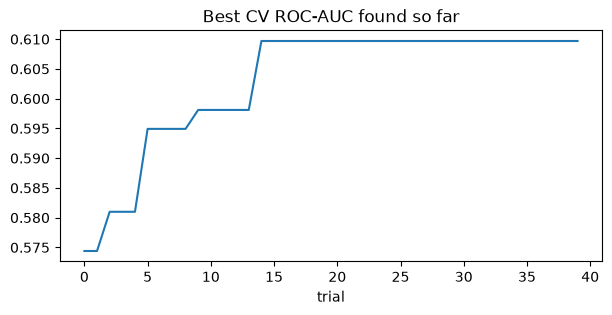

In [9]:
trials = study.trials_dataframe()
print(trials["value"].describe().round(3))

ax = trials["value"].cummax().plot(figsize=(7, 3), title="Best CV ROC-AUC found so far")
ax.set_xlabel("trial")
plt.show()

## 4. Default vs. tuned: the one look at validation

In [10]:
best_xgb_params = {**FIXED_XGB, **study.best_params}

default_rf.fit(X_train, y_train)
default_xgb.fit(X_train, y_train)
tuned_rf = grid.best_estimator_
tuned_xgb = XGBClassifier(**best_xgb_params).fit(X_train, y_train)

candidates = {
    "rf_default": default_rf,
    "rf_tuned": tuned_rf,
    "xgb_default": default_xgb,
    "xgb_tuned": tuned_xgb,
}

rows = {}
for name, model in candidates.items():
    pred = model.predict(X_val)
    proba = model.predict_proba(X_val)[:, 1]
    rows[name] = {
        "cv_auc": cv_auc(model).mean(),
        **evaluate_classifier(y_val, pred, proba),
    }

summary = pd.DataFrame.from_dict(rows, orient="index").round(3)
summary["cv_minus_val_auc"] = (summary["cv_auc"] - summary["roc_auc"]).round(3)
summary

,cv_auc,accuracy,precision,recall,f1,roc_auc,cv_minus_val_auc
rf_default,0.611,0.449,0.404,0.784,0.533,0.547,0.064
rf_tuned,0.611,0.449,0.404,0.784,0.533,0.547,0.064
xgb_default,0.595,0.480,0.416,0.725,0.529,0.561,0.034
xgb_tuned,0.610,0.543,0.448,0.588,0.508,0.582,0.028


In [11]:
for name in ["xgb_default", "xgb_tuned"]:
    s = cv_auc(candidates[name])
    print(f"{name:12s} per-fold {np.round(s, 3)}  mean {s.mean():.3f}")

xgb_default  per-fold [0.658 0.567 0.582 0.536 0.63 ]  mean 0.595
xgb_tuned    per-fold [0.652 0.558 0.605 0.591 0.642]  mean 0.610


In [12]:
summary.to_csv("docs/results/day16_tuning.csv")

Path("docs/results/day16_best_params.json").write_text(
    json.dumps({"rf": best_rf_params, "xgb": best_xgb_params}, indent=2),
    encoding="utf-8",
)

479